In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore', category = FutureWarning) 
pd.set_option('display.max_columns', None) 

In [2]:
df_hrlimpio=pd.read_csv("hr_clean.csv")

In [5]:
tabla_ot=pd.crosstab(df_hrlimpio['OverTime'], df_hrlimpio['Attrition'], normalize='index') * 100

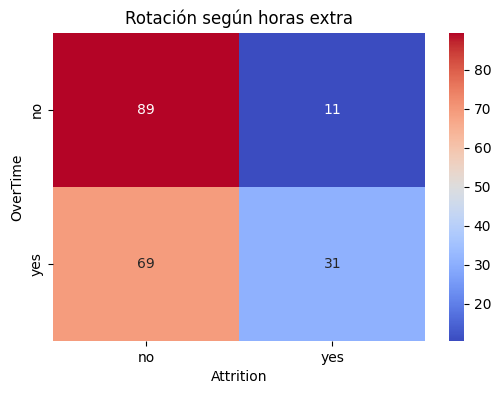

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(tabla_ot, annot=True, cmap='coolwarm')

plt.title("Rotación según horas extra")
plt.show()

el over time esta claramente relacionado con la rotacion sin horas extras solo el 10% se va sin embargo con horas extras el 31 % se va.

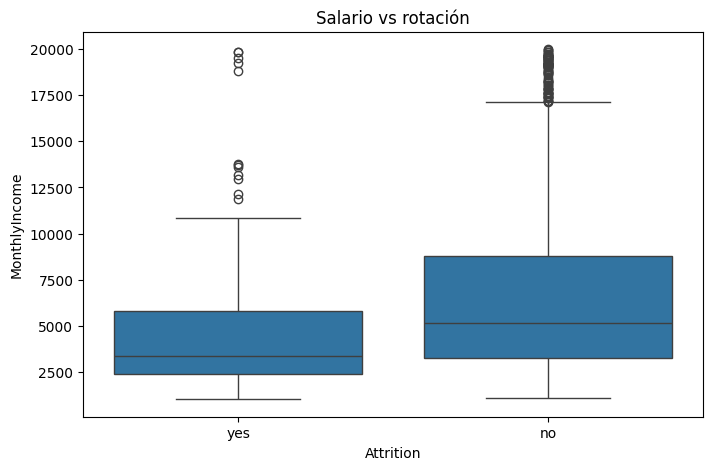

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_hrlimpio,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title("Salario vs rotación")
plt.show()

aqui estamos comparando salario vs rotacion y se detecta que los que se van tienen la emdiana mas baja, caja concentrada en salarios mas bajos ganan menos en general , la gente con salarios mas bajos tiende a irse mas.

In [8]:
tabla_riesgo = pd.crosstab(
    [df_hrlimpio['OverTime'], df_hrlimpio['JobSatisfaction']],
    df_hrlimpio['Attrition'],
    normalize='index'
) * 100

tabla_riesgo

Attrition                        no        yes
OverTime JobSatisfaction                      
no       1.0              82.125604  17.874396
         2.0              90.291262   9.708738
         3.0              89.880952  10.119048
         4.0              93.354430   6.645570
yes      1.0              64.473684  35.526316
         2.0              62.318841  37.681159
         3.0              65.289256  34.710744
         4.0              78.417266  21.582734

Mayor concentración de empleados  entre 30 y 40 años y es donde hay mas casos de desercion pero porque hay más empleados en ese rango
Los empleados más jóvenes tienden a irse más
En edades entre 20 y 30, la proporción de los que se van parece  más alta.
Los jóvenes podrían tener mayor rotación.

<Axes: xlabel='Department', ylabel='count'>

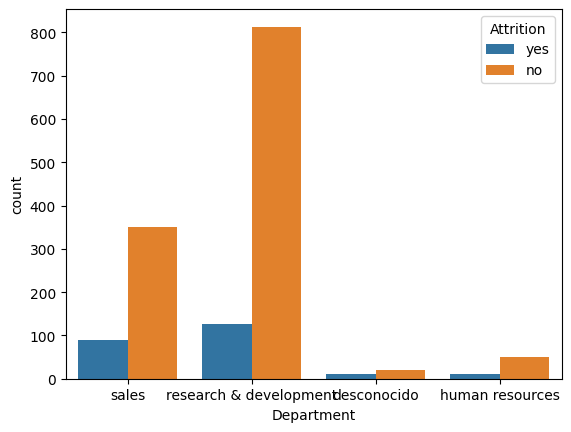

In [10]:
pd.crosstab(df_hrlimpio['Department'], df_hrlimpio['Attrition'], normalize='index') * 100
sns.countplot(data= df_hrlimpio, x="Department", hue="Attrition")

relacion departamento y desercion

RELACION CON HORAS EXTRAS

<Axes: xlabel='OverTime', ylabel='count'>

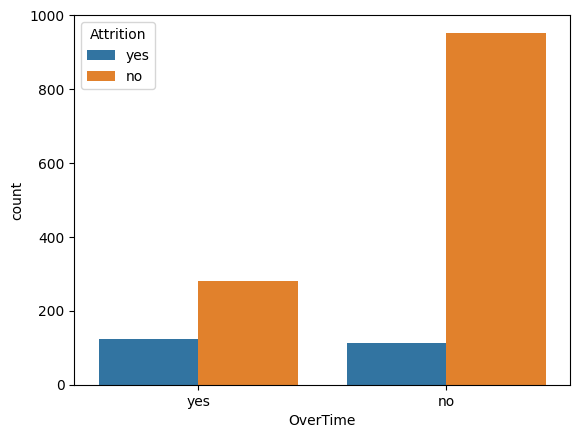

In [11]:
pd.crosstab(df_hrlimpio['OverTime'], df_hrlimpio['Attrition'], normalize='index') * 100     #horas extras
sns.countplot(data= df_hrlimpio, x="OverTime", hue="Attrition")

Empleados que NO hacen horas extraS (OverTime = no) la gran mayoria que no hace horas extras no se van.
La cantidad de deserción es mucho menor comparada con los que hacen horas extra. En ambos grupos hay más empleados que se quedan

relacion con la distancia al trabajo.

<Axes: xlabel='DistanceFromHome', ylabel='Attrition'>

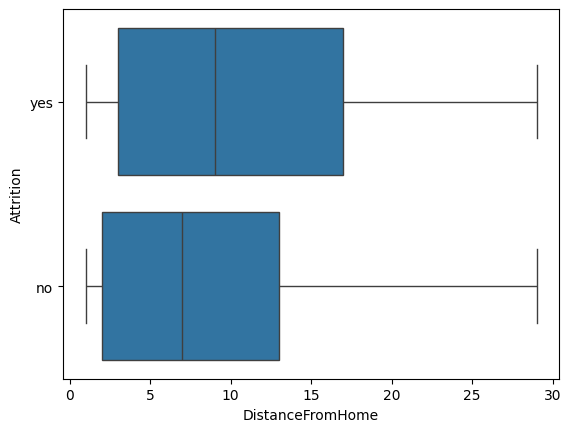

In [13]:
df_hrlimpio.groupby("Attrition")["DistanceFromHome"].mean()
sns.boxplot(data=df_hrlimpio, x="DistanceFromHome", y="Attrition")

La distancia al trabajo parece influir en la deserción, ya que los empleados que renuncian tienden a vivir más lejos. Pero la diferencia no es lo suficientemente  como para ser un factor determinante.

Riesgo Rojo: Soltero + Horas Extra + Satisfacción x
  🟡 Riesgo Amarillo: Vive lejos + Nivel de trabajo 1 + Sin aumento reciente.
  🟢 Riesgo Verde: Casado + Sin horas extra + Alta satisfacción.